# 01 - General EDA: Russia Sanctions, Markets and Trade (2014–2026)

**Scope.** Exploratory analysis of five linked datasets covering the 2014–2026 Russia sanctions period:

| File | Content | Frequency |
|---|---|---|
| `sanctions_events.csv` | 60 individual sanctions actions (US/EU/UK/G7) | event-level |
| `equity_index_daily.csv` | MOEX, RTS, OFZ yield, RUONIA, USD/RUB, trading-halt flag | daily |
| `commodities_daily.csv` | Brent, Urals, ESPO, spreads, TTF gas, wheat, urea, aluminium | daily |
| `macro_monthly.csv` | CBR rate, CPI, GDP, reserves, oil/gas budget share, sanctions intensity | monthly |
| `trade_flows_monthly.csv` | Export/import shares & values by partner country | monthly |

This notebook establishes data quality, key stylized facts, and visual context that
motivate the event-study (`02_event_study.ipynb`) and price-cap analysis
(`03_oil_price_cap.ipynb`).


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.titleweight'] = 'bold'

DATA = '../data'  # CSVs are expected alongside this notebook


## 1. Load & data-quality overview

In [41]:
equity = pd.read_csv(f'{DATA}/equity_index_daily.csv', parse_dates=['date'])
comm   = pd.read_csv(f'{DATA}/commodities_daily.csv', parse_dates=['date'])
macro  = pd.read_csv(f'{DATA}/macro_monthly.csv')
trade  = pd.read_csv(f'{DATA}/trade_flows_monthly.csv')
events = pd.read_csv(f'{DATA}/sanctions_events.csv', parse_dates=['date'])

dq_rows = []
for name, df in [('equity_index_daily', equity), ('commodities_daily', comm),
                  ('macro_monthly', macro), ('trade_flows_monthly', trade),
                  ('sanctions_events', events)]:
    dq_rows.append(dict(
        dataset=name, rows=len(df), cols=df.shape[1],
        missing_cells=int(df.isna().sum().sum()),
        pct_missing=round(100*df.isna().sum().sum()/df.size, 3),
    ))
dq = pd.DataFrame(dq_rows)
dq


,dataset,rows,cols,missing_cells,pct_missing
0,equity_index_daily,3217,8,36,0.14
1,commodities_daily,3217,11,0,0.00
2,macro_monthly,148,17,0,0.00
3,trade_flows_monthly,1480,8,0,0.00
4,sanctions_events,60,19,0,0.00


In [42]:
# Date coverage
print('equity_index_daily :', equity.date.min().date(), '->', equity.date.max().date(), f'({len(equity)} trading days)')
print('commodities_daily  :', comm.date.min().date(), '->', comm.date.max().date(), f'({len(comm)} trading days)')
print('macro_monthly      :', macro.year_month.min(), '->', macro.year_month.max(), f'({len(macro)} months)')
print('sanctions_events   :', events.date.min().date(), '->', events.date.max().date(), f'({len(events)} actions)')

missing = equity[equity.moex_index.isna()]
print(f"\nMOEX index missing on {len(missing)} days -> trading-halt period: {missing.date.min().date()} to {missing.date.max().date()}")
print("(Confirms the ~4-week MOEX closure following the Feb 2022 invasion / initial sanctions wave.)")


equity_index_daily : 2014-01-01 -> 2026-04-30 (3217 trading days)
commodities_daily  : 2014-01-01 -> 2026-04-30 (3217 trading days)
macro_monthly      : 2014-01 -> 2026-04 (148 months)
sanctions_events   : 2014-03-17 -> 2026-02-24 (60 actions)

MOEX index missing on 18 days -> trading-halt period: 2022-02-28 to 2022-03-23
(Confirms the ~4-week MOEX closure following the Feb 2022 invasion / initial sanctions wave.)


**Data quality summary.** All five files are clean at the column level (no missing
values except a deliberate one: `moex_index`/`rts_index` are `NaN` for 18 trading days
in Feb–Mar 2022, which is the real MOEX trading halt, not a data error — this is
carried through the notebooks rather than imputed, since inventing a price during a
closed market would misrepresent what actually happened.

## 2. Sanctions timeline and intensity

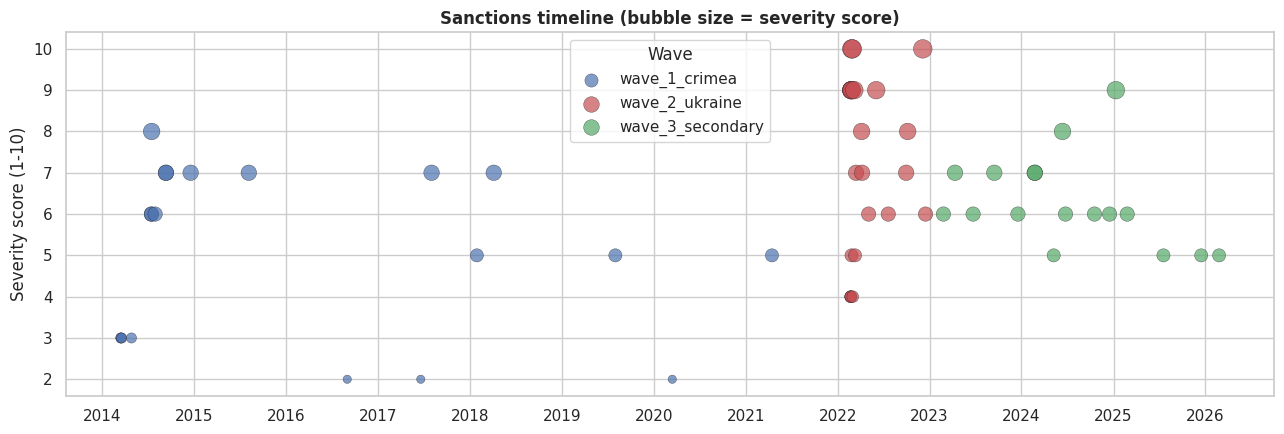

In [43]:
fig, ax = plt.subplots(figsize=(13,4.5))
wave_colors = {'wave_1_crimea':'#4C72B0','wave_2_ukraine':'#C44E52','wave_3_secondary':'#55A868'}
for wave, sub in events.groupby('wave'):
    ax.scatter(sub.date, sub.severity_score, s=sub.severity_score*18, alpha=0.7,
               color=wave_colors.get(wave,'grey'), label=wave, edgecolor='k', linewidth=0.3)
ax.set_title('Sanctions timeline (bubble size = severity score)')
ax.set_ylabel('Severity score (1-10)')
ax.legend(title='Wave', loc='upper center')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(f'../output/eda_sanctions_timeline.png', dpi=300, bbox_inches='tight') 
plt.show()



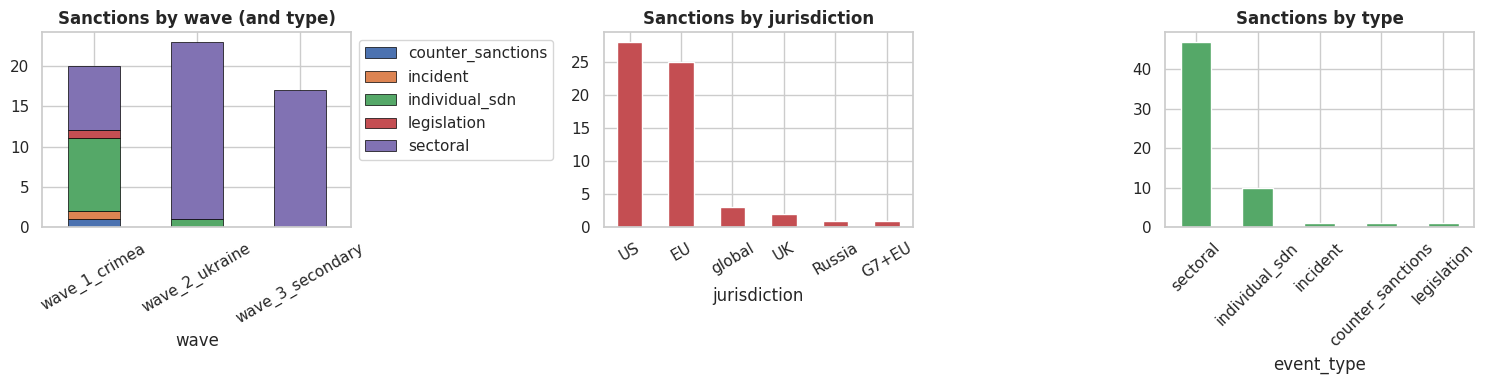

Sector flags (share of actions):
is_financial     0.17
is_energy        0.15
is_individual    0.17
is_sectoral      0.78
dtype: float64


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
ct = pd.crosstab(events['wave'], events['event_type'])
ct.plot(kind='bar', stacked=True, ax=axes[0], edgecolor='black', linewidth=0.5)
axes[0].set_title('Sanctions by wave (and type)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(loc='upper left',bbox_to_anchor=(1,1))

events.jurisdiction.value_counts().plot.bar(ax=axes[1], color='#C44E52')
axes[1].set_title('Sanctions by jurisdiction')
axes[1].tick_params(axis='x', rotation=30)

events.event_type.value_counts().plot.bar(ax=axes[2], color='#55A868')
axes[2].set_title('Sanctions by type')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'../output/eda_sanctions_overview.png', dpi=300, bbox_inches='tight') 
plt.show()

print('Sector flags (share of actions):')
print(events[['is_financial','is_energy','is_individual','is_sectoral']].mean().round(2))


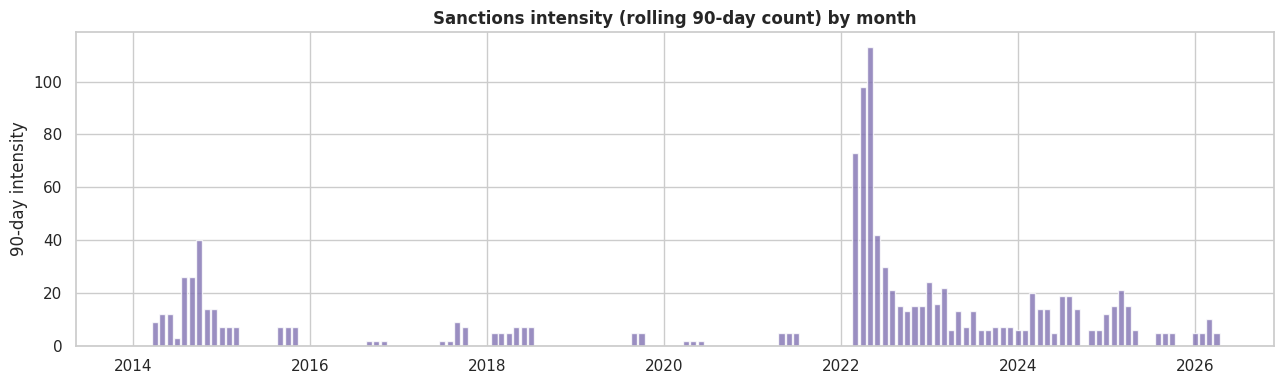

In [45]:
fig, ax = plt.subplots(figsize=(13,4))
macro_plot = macro.copy()
macro_plot['date'] = pd.to_datetime(macro_plot['year_month'])
ax.bar(macro_plot.date, macro_plot.sanctions_intensity_90d, width=25, color='#8172B2', alpha=0.8)
ax.set_title('Sanctions intensity (rolling 90-day count) by month')
ax.set_ylabel('90-day intensity')
plt.tight_layout()
plt.savefig(f'../output/eda_sanctions_density.png', dpi=300, bbox_inches='tight') 
plt.show()


**Reading.** Wave 1 (Crimea, 2014) was sparse and mostly individual/SDN listings.
Wave 2 (full-scale invasion, 2022) compresses ~14 discrete actions into roughly three
weeks — this clustering is the central econometric problem addressed in the event
study. Wave 3 (secondary sanctions/enforcement, 2023–2026) is steadier but still
sectoral and frequent, which will turn out to leave very few "clean" (uncontaminated)
event windows in the post-2022 period.

## 3. Markets: MOEX, RUB, rates

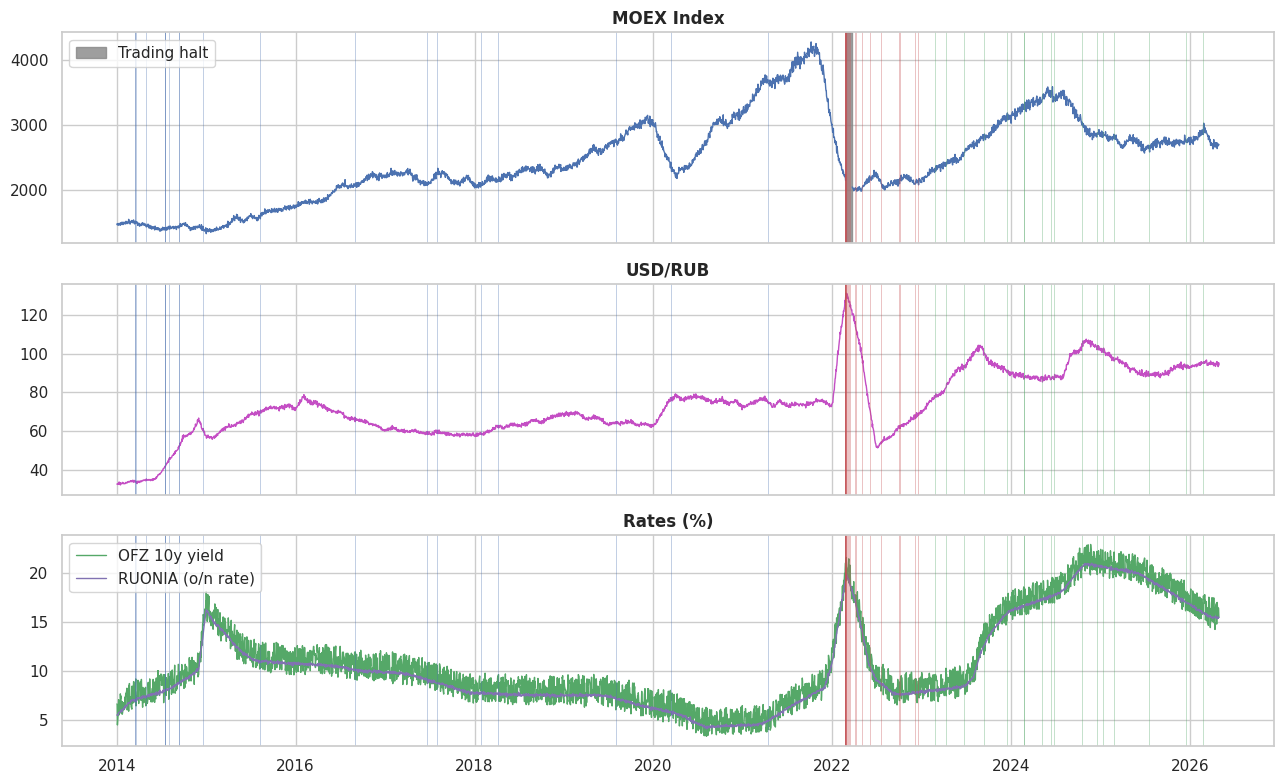

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(13,8), sharex=True)

axes[0].plot(equity.date, equity.moex_index, color='#4C72B0', lw=1)
halted = equity[equity.moex_trading_halted==1]
if len(halted):
    axes[0].axvspan(halted.date.min(), 
                    halted.date.max(), 
                    color="#868686", alpha=0.8, 
                    label='Trading halt')
axes[0].set_title('MOEX Index'); axes[0].legend(loc='upper left')

axes[1].plot(equity.date, equity.usd_rub, color="#C44EC4", lw=1)
axes[1].set_title('USD/RUB')

axes[2].plot(equity.date, equity.ofz_10y_yield_pct, color='#55A868', lw=1, label='OFZ 10y yield')
axes[2].plot(equity.date, equity.ruonia_pct, color='#8172B2', lw=1, label='RUONIA (o/n rate)')
axes[2].set_title('Rates (%)'); axes[2].legend(loc='upper left')

for e_date, e_wave in zip(events.date, events.wave):
    for ax in axes: ax.axvline(e_date, 
                               color=wave_colors.get(e_wave,'grey'), 
                               alpha=0.4, lw=0.6)

plt.tight_layout()
plt.savefig(f'../output/eda_markets.png', dpi=300, bbox_inches='tight')
plt.show()


Grey vertical lines mark every sanctions action. The 2022 cluster is visually dense; later waves are sparser but still land close together in places (e.g. late 2022, early 2024).

## 4. Commodities: Brent, Urals, ESPO and the discount

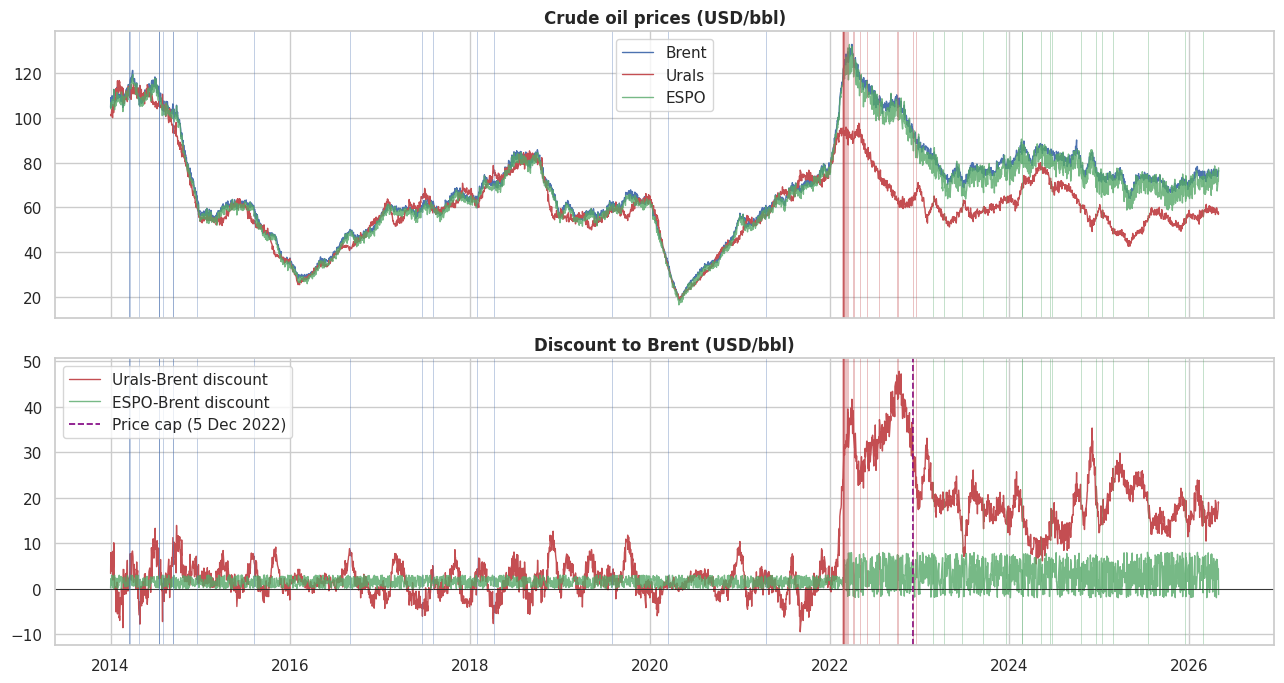

Mean Urals-Brent discount, pre-war (<2022-02-24): 1.87 USD/bbl (3.0% of Brent)
Mean Urals-Brent discount, post-cap (>=2022-12-05): 17.93 USD/bbl (23.2% of Brent)


In [47]:
fig, axes = plt.subplots(2, 1, figsize=(13,7), sharex=True)

axes[0].plot(comm.date, comm.brent_usd_bbl, label='Brent', color='#4C72B0', lw=1)
axes[0].plot(comm.date, comm.urals_usd_bbl, label='Urals', color='#C44E52', lw=1)
axes[0].plot(comm.date, comm.espo_usd_bbl, label='ESPO', color='#55A868', lw=1, alpha=0.8)
axes[0].set_title('Crude oil prices (USD/bbl)')
axes[0].legend(loc='upper center')

axes[1].plot(comm.date, comm.urals_brent_spread_usd, color='#C44E52', lw=1, label='Urals-Brent discount')
axes[1].plot(comm.date, comm.espo_brent_spread_usd, color='#55A868', lw=1, alpha=0.8, label='ESPO-Brent discount')
axes[1].axhline(0, color='k', lw=0.6)
axes[1].axvline(pd.Timestamp('2022-12-05'), color='purple', ls='--', lw=1.2, label='Price cap (5 Dec 2022)')
axes[1].set_title('Discount to Brent (USD/bbl)')
axes[1].legend(loc='upper left')

for e_date, e_wave in zip(events.date, events.wave):
    for ax in axes: ax.axvline(e_date, 
                               color=wave_colors.get(e_wave,'grey'), 
                               alpha=0.4, lw=0.6)

plt.tight_layout()
plt.savefig(f'../output/eda_commodities.png', dpi=300, bbox_inches='tight') 
plt.show()

pre_war = comm[comm.date < '2022-02-24']
post_cap = comm[comm.date >= '2022-12-05']
print(f"Mean Urals-Brent discount, pre-war (<2022-02-24): {pre_war.urals_brent_spread_usd.mean():.2f} USD/bbl "
      f"({100*pre_war.urals_brent_spread_usd.mean()/pre_war.brent_usd_bbl.mean():.1f}% of Brent)")
print(f"Mean Urals-Brent discount, post-cap (>=2022-12-05): {post_cap.urals_brent_spread_usd.mean():.2f} USD/bbl "
      f"({100*post_cap.urals_brent_spread_usd.mean()/post_cap.brent_usd_bbl.mean():.1f}% of Brent)")


The discount widens sharply after the invasion and stays structurally wider through the price-cap period — this is quantified properly in notebook 03.

## 5. Macro & fiscal context

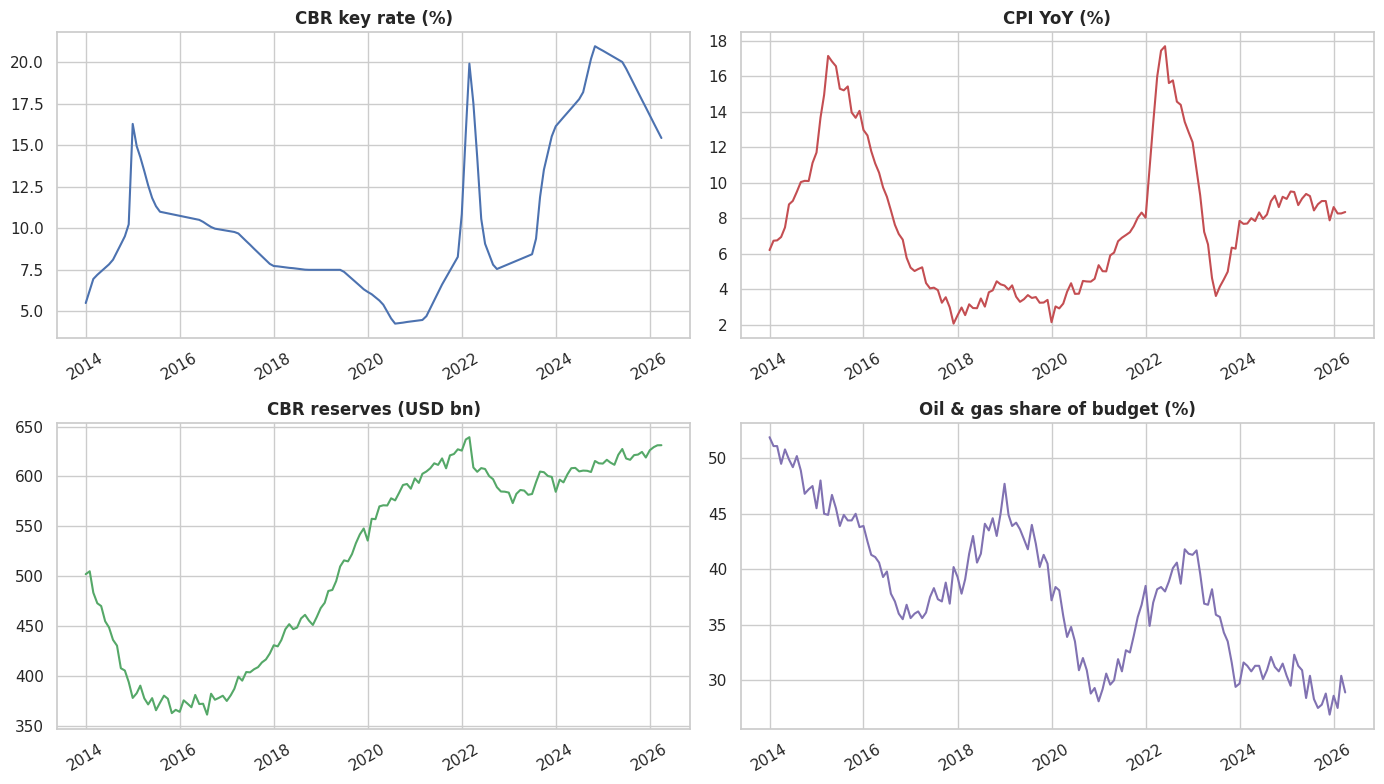

In [55]:
macro_plot = macro.copy()
macro_plot['date'] = pd.to_datetime(macro_plot['year_month'])

fig, axes = plt.subplots(2, 2, figsize=(14,8))
axes[0,0].plot(macro_plot.date, macro_plot.cbr_key_rate_pct, color='#4C72B0'); axes[0,0].set_title('CBR key rate (%)')
axes[0,1].plot(macro_plot.date, macro_plot.cpi_yoy_pct, color='#C44E52'); axes[0,1].set_title('CPI YoY (%)')
axes[1,0].plot(macro_plot.date, macro_plot.cbr_reserves_usd_bn, color='#55A868'); axes[1,0].set_title('CBR reserves (USD bn)')
axes[1,1].plot(macro_plot.date, macro_plot.oil_gas_share_budget_pct, color='#8172B2'); axes[1,1].set_title('Oil & gas share of budget (%)')
for ax in axes.ravel(): 
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'../output/eda_macro.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Trade reorientation: partner shares

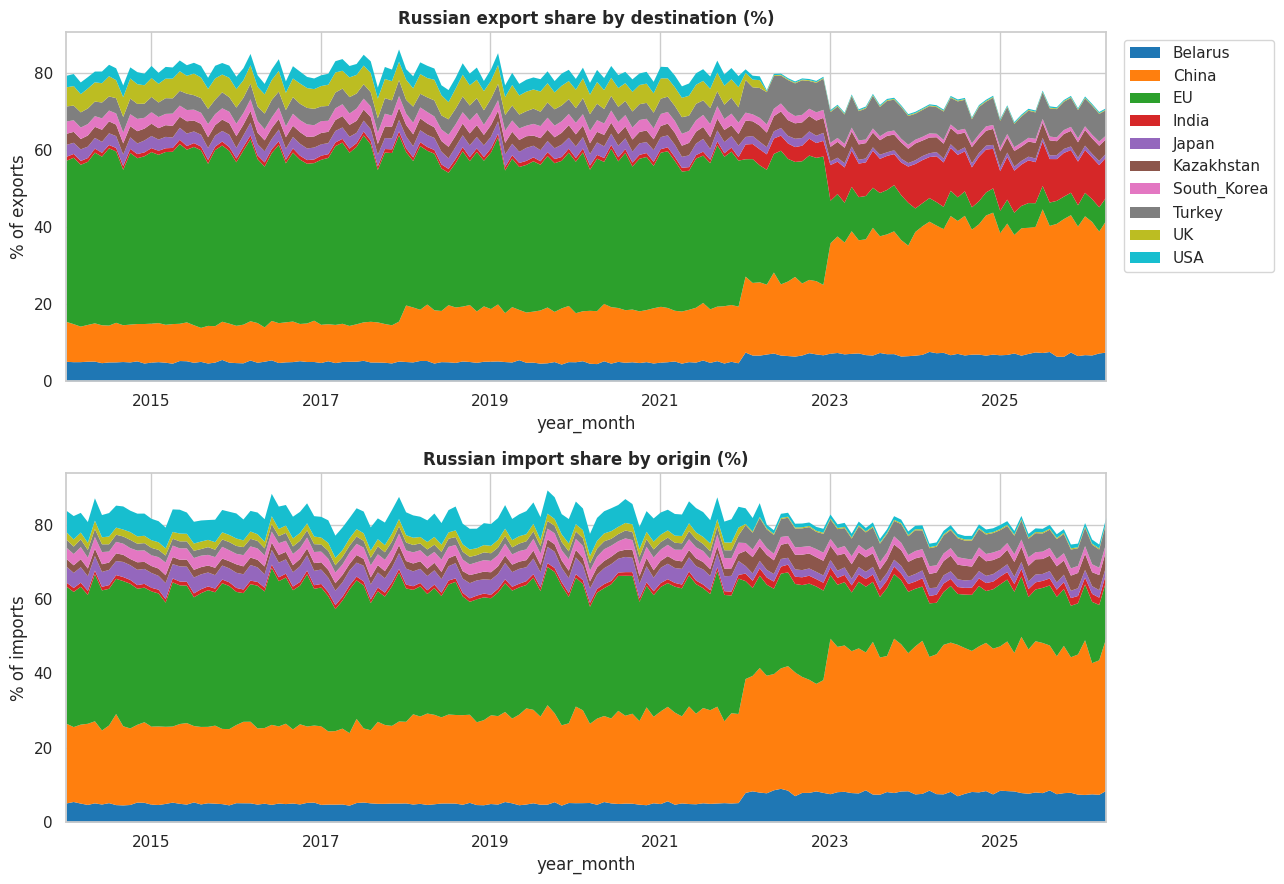

Export share, first vs last available month:
year_month   2014-01-01  2026-04-01
partner                            
Belarus             5.1         7.5
China              10.4        34.3
EU                 41.9         6.1
India               1.0        10.4
Japan               3.1         1.0
Kazakhstan          2.9         3.8
South_Korea         3.2         0.9
Turkey              3.9         6.6
UK                  5.0         0.2
USA                 3.0         0.3
Import share, first vs last available month:
year_month   2014-01-01  2026-04-01
partner                            
Belarus             5.1         8.5
China              21.4        41.1
EU                 36.9        15.4
India               1.1         2.1
Japan               4.3         2.0
Kazakhstan          2.0         4.2
South_Korea         3.0         2.0
Turkey              2.2         5.4
UK                  2.0         0.3
USA                 5.8         1.1


In [ ]:
piv = trade.pivot_table(index='year_month', columns='partner', values='exports_share_pct', aggfunc='mean')
piv.index = pd.to_datetime(piv.index)
piv = piv.sort_index()

piv_i = trade.pivot_table(index='year_month', columns='partner', values='imports_share_pct', aggfunc='mean')
piv_i.index = pd.to_datetime(piv_i.index)
piv_i = piv_i.sort_index()

fig, ax = plt.subplots(2,1,figsize=(13,9))
piv.plot.area(ax=ax[0], cmap='tab10', linewidth=0)
piv_i.plot.area(ax=ax[1], cmap='tab10', linewidth=0, legend=False)
ax[0].set_title('Russian export share by destination (%)')
ax[1].set_title('Russian import share by origin (%)')
ax[0].set_ylabel('% of exports')
ax[1].set_ylabel('% of imports')
ax[0].legend(loc='upper left', bbox_to_anchor=(1.01,1))
#ax[1].legend(loc='upper left', bbox_to_anchor=(1.01,1))
plt.tight_layout()
plt.savefig(f'../output/eda_trade_reorientation.png', dpi=300, bbox_inches='tight')
plt.show()

print('Export share, first vs last available month:')
print(piv.iloc[[0,-1]].round(1).T)

print('Import share, first vs last available month:')
print(piv_i.iloc[[0,-1]].round(1).T)

**Reading.** The classic reorientation story: EU export share collapses while China/India/Turkey rise, consistent with sanctions-driven redirection of trade flows toward non-aligned buyers.

## 7. Correlation structure of daily returns

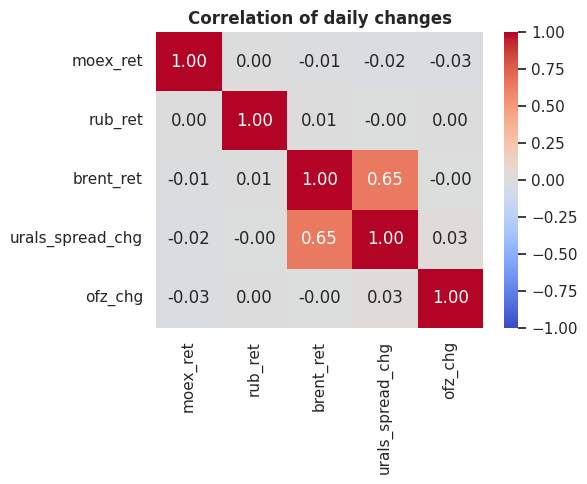

In [59]:
mkt = equity.merge(comm, on=['date','year'], how='inner').sort_values('date')
mkt['moex_ret'] = np.log(mkt.moex_index).diff()
mkt['rub_ret']  = np.log(mkt.usd_rub).diff()
mkt['brent_ret'] = np.log(mkt.brent_usd_bbl).diff()
mkt['urals_spread_chg'] = mkt.urals_brent_spread_usd.diff()
mkt['ofz_chg'] = mkt.ofz_10y_yield_pct.diff()

ret_cols = ['moex_ret','rub_ret','brent_ret','urals_spread_chg','ofz_chg']
corr = mkt[ret_cols].corr()

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation of daily changes')
plt.tight_layout()
plt.savefig(f'../output/eda_correlation.png', dpi=300, bbox_inches='tight')
plt.show()


**Comment.** Brent return and Urals spread change are moderately correlated.

## Summary of stylized facts feeding into notebooks 02–03

1. Sanctions actions cluster heavily around Feb–Mar 2022 (14 actions in ~3 weeks) and remain frequent (2-3 months apart) through 2023–2026 — **event windows will overlap and must be clustered/de-contaminated**, not treated as 39+ independent shocks.
2. MOEX was **halted for ~4 weeks** after the invasion — CAR calculations must be robust to this data gap.
3. The Urals-Brent discount widens materially and persistently after the invasion/price cap, well beyond the pre-war baseline — quantified formally in notebook 03.
4. Trade flows reoriented from EU toward China/India/Turkey over the sample.
